In [7]:
import sys
sys.path.append('..')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from datetime import datetime
from pathlib import Path

from src.signals.signal import load_signals
from src.signals.residuals import load_residuals
from src.utils.plotting import ic_decay, quintile_returns
from src.utils.stats import newey_west_tstat, icir

plt.rcParams.update({
    'figure.figsize':    (13, 4),
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

S = load_signals()
R = load_residuals()

dates_str = sorted(S['rebal_date'].unique().cast(pl.Utf8).to_list())
dates_dt  = [datetime.strptime(d, '%Y-%m-%d') for d in dates_str]

print(f'Signals : {S.shape}  |  {dates_str[0]} to {dates_str[-1]}')

Signals : (41607, 6)  |  2007-10-31 to 2024-12-31


Cross-sectional distribution of z-scores and alphas pooled across all dates.
z-scores should be symmetric around 0 with std close to 1.
Alphas should be symmetric around 0 with heavier tails from the idio_vol scaling.

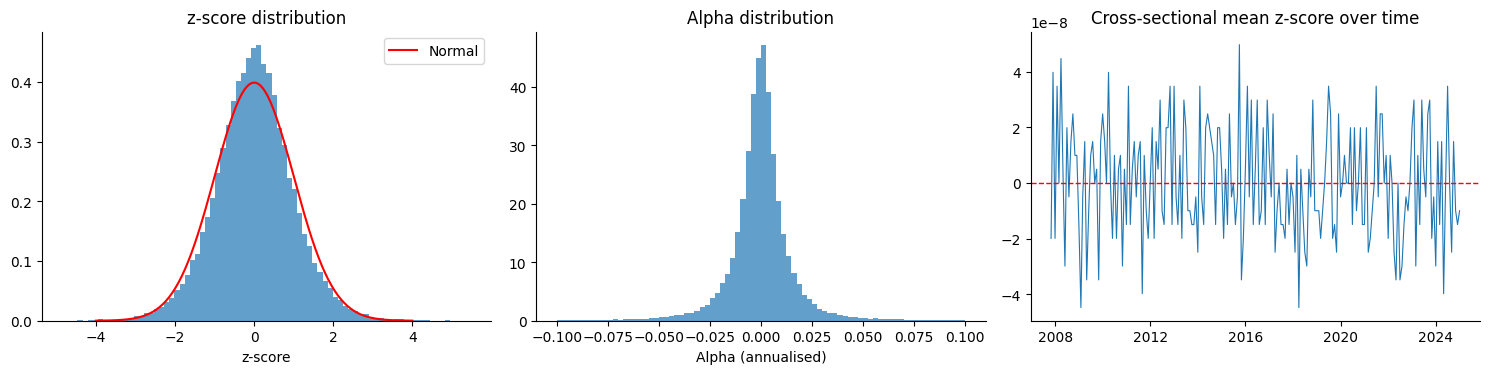

z-score mean: 0.0000  std: 0.9748  skew: 0.0345
alpha mean: 0.000146  std: 0.0194


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# z-score distribution
z = S['z_score'].to_numpy()
axes[0].hist(z, bins=80, density=True, alpha=0.7)
x = np.linspace(-4, 4, 200)
axes[0].plot(x, stats.norm.pdf(x), 'r-', linewidth=1.5, label='Normal')
axes[0].set_title('z-score distribution')
axes[0].set_xlabel('z-score')
axes[0].legend()

# alpha distribution
a = S['alpha'].to_numpy()
axes[1].hist(a, bins=80, density=True, alpha=0.7, range=(-0.1, 0.1))
axes[1].set_title('Alpha distribution')
axes[1].set_xlabel('Alpha (annualised)')

# cross-sectional mean z-score per date
cs_mean = (
    S.group_by('rebal_date')
     .agg(pl.col('z_score').mean().alias('mean_z'))
     .sort('rebal_date')
)
axes[2].plot(dates_dt, cs_mean['mean_z'].to_numpy(), linewidth=0.8)
axes[2].axhline(0, color='r', linestyle='--', linewidth=1)
axes[2].set_title('Cross-sectional mean z-score over time')
axes[2].xaxis.set_major_locator(mdates.YearLocator(4))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
save_fig("04_signals_zscore_alpha_dist.png")
plt.show()

print(f'z-score mean: {z.mean():.4f}  std: {z.std():.4f}  skew: {stats.skew(z):.4f}')
print(f'alpha mean: {a.mean():.6f}  std: {a.std():.4f}')

The IC is the Spearman rank correlation between the alpha forecast at month-end $t$
and the subsequent month's realised residual return:

$$\text{IC}_t = \text{Spearman}(\alpha_t^i,\ \epsilon_{[t,t+21]}^i)_{i=1}^{N_t}$$

A mean IC > 0 with t-stat > 2 means the signal has statistically significant predictive power.

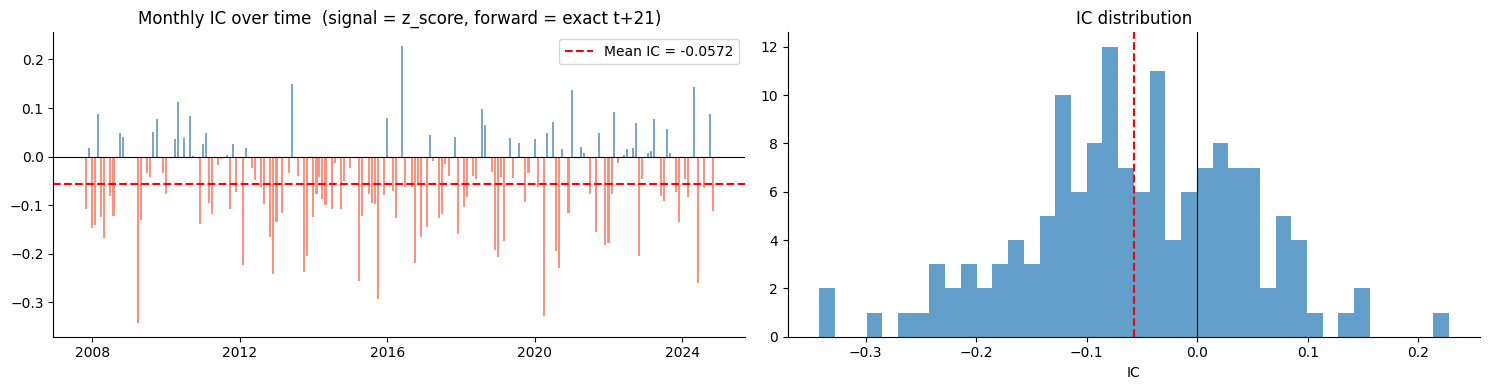

Mean IC     : -0.0572
Std IC      : 0.0999
t-stat iid  : -6.8932
t-stat NW   : -7.5212  (HAC, max_lag=6)
% positive  : 31.0%


-0.5704719499166537

In [9]:
all_dates   = sorted(R['date'].unique().to_list())
date_to_idx = {d: i for i, d in enumerate(all_dates)}

def fwd_date(d, n=21):
    idx = date_to_idx.get(d)
    if idx is None or idx + n >= len(all_dates):
        return None
    return all_dates[idx + n]

rebal_dates = S['rebal_date'].unique().sort()
ic_records  = []

for d in rebal_dates.to_list()[:-1]:
    d_fwd = fwd_date(d, 21)
    if d_fwd is None:
        continue

    signals_d = S.filter(pl.col('rebal_date') == d).select(['symbol', 'z_score'])

    fwd = (
        R.filter(pl.col('symbol').is_in(signals_d['symbol'].to_list()))
         .filter((pl.col('date') > d) & (pl.col('date') <= d_fwd))
         .group_by('symbol')
         .agg(pl.col('residual').sum().alias('fwd_ret'))
         .drop_nulls()
)

    merged = signals_d.join(fwd, on='symbol', how='inner')
    if len(merged) < 20:
        continue

    ic = stats.spearmanr(
        merged['z_score'].to_numpy(),
        merged['fwd_ret'].to_numpy()
    ).statistic
    ic_records.append({'date': d, 'ic': float(ic), 'n': len(merged)})

ic_df    = pl.DataFrame(ic_records)
ic_arr   = ic_df['ic'].to_numpy()
ic_dates = [datetime.strptime(str(d), '%Y-%m-%d') for d in ic_df['date'].to_list()]

mean_ic  = ic_arr.mean()
std_ic   = ic_arr.std()
t_iid    = mean_ic / (std_ic / np.sqrt(len(ic_arr)))
t_nw     = newey_west_tstat(ic_arr, max_lag=6)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].bar(ic_dates, ic_arr, width=20,
            color=['steelblue' if v > 0 else 'tomato' for v in ic_arr], alpha=0.7)
axes[0].axhline(0,       color='k',   linewidth=0.8)
axes[0].axhline(mean_ic, color='red', linewidth=1.5, linestyle='--',
                label=f'Mean IC = {mean_ic:.4f}')
axes[0].set_title('Monthly IC over time  (signal = z_score, forward = exact t+21)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator(4))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].hist(ic_arr, bins=40, alpha=0.7)
axes[1].axvline(0,       color='k',   linewidth=0.8)
axes[1].axvline(mean_ic, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('IC distribution')
axes[1].set_xlabel('IC')

plt.tight_layout()
save_fig("04_signals_ic_time_dist.png")
plt.show()

print(f'Mean IC     : {mean_ic:.4f}')
print(f'Std IC      : {std_ic:.4f}')
print(f't-stat iid  : {t_iid:.4f}')
print(f't-stat NW   : {t_nw:.4f}  (HAC, max_lag=6)')
print(f'% positive  : {(ic_arr > 0).mean():.1%}')

icir(ic_arr)

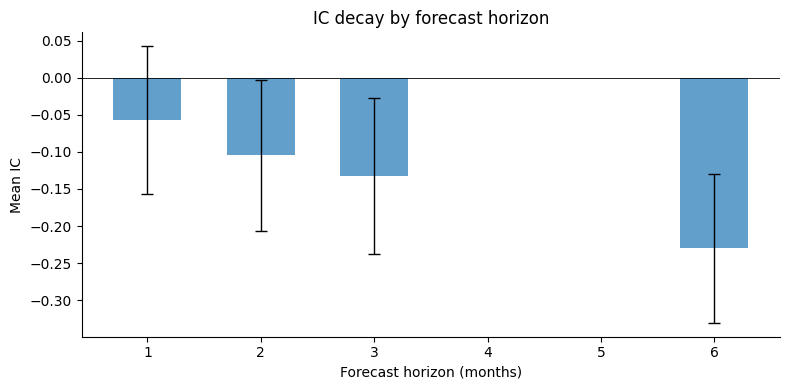

In [10]:
horizons = [21, 42, 63, 126]
ic_means = []
ic_stds = []

for h in horizons:
    ic_list = []
    for d in rebal_dates.to_list()[:-1]:
        d_fwd = fwd_date(d, h)
        if d_fwd is None:
            continue
        signals_d = S.filter(pl.col('rebal_date') == d).select(['symbol', 'z_score'])
        fwd = (
            R.filter(pl.col('symbol').is_in(signals_d['symbol'].to_list()))
             .filter((pl.col('date') > d) & (pl.col('date') <= d_fwd))
             .group_by('symbol')
             .agg(pl.col('residual').sum().alias('fwd_ret'))
             .drop_nulls()
)
        merged = signals_d.join(fwd, on='symbol', how='inner')
        if len(merged) < 20:
            continue
        ic_h = stats.spearmanr(
            merged['z_score'].to_numpy(),
            merged['fwd_ret'].to_numpy()
        ).statistic
        ic_list.append(ic_h)
    ic_arr_h = np.array(ic_list)
    ic_means.append(ic_arr_h.mean() if len(ic_arr_h) else np.nan)
    ic_stds.append(ic_arr_h.std() if len(ic_arr_h) else np.nan)

fig, ax = plt.subplots(figsize=(8, 4))
ic_decay([1, 2, 3, 6], ic_means, ic_stds, ax=ax)
plt.tight_layout()
save_fig("04_signals_ic_decay.png")
plt.show()

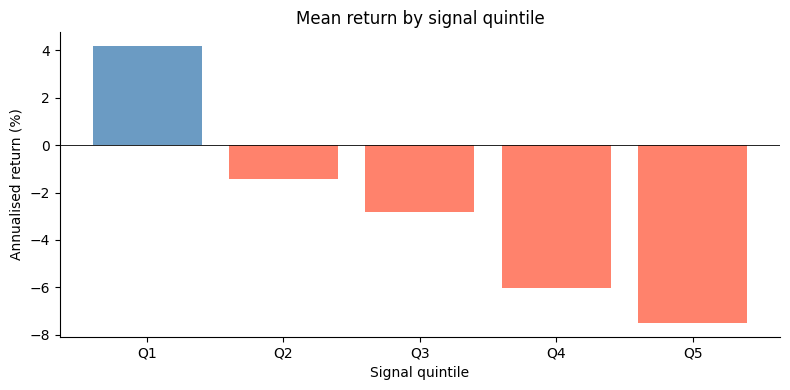

In [11]:
q_means = np.zeros(5)
q_counts = np.zeros(5)

for d in rebal_dates.to_list()[:-1]:
    d_fwd = fwd_date(d, 21)
    if d_fwd is None:
        continue
    signals_d = S.filter(pl.col('rebal_date') == d).select(['symbol', 'z_score'])
    fwd = (
        R.filter(pl.col('symbol').is_in(signals_d['symbol'].to_list()))
         .filter((pl.col('date') > d) & (pl.col('date') <= d_fwd))
         .group_by('symbol')
         .agg(pl.col('residual').sum().alias('fwd_ret'))
         .drop_nulls()
)
    merged = signals_d.join(fwd, on='symbol', how='inner')
    if len(merged) < 20:
        continue
    z = merged['z_score'].to_numpy()
    r = merged['fwd_ret'].to_numpy()
    q = np.floor(np.argsort(np.argsort(z)) / len(z) * 5).astype(int)
    q = np.clip(q, 0, 4)
    for i in range(5):
        mask = q == i
        if mask.any():
            q_means[i] += r[mask].mean()
            q_counts[i] += 1

q_means = np.divide(q_means, q_counts, out=np.zeros_like(q_means), where=q_counts>0)
fig, ax = plt.subplots(figsize=(8, 4))
quintile_returns(q_means, periods_per_year=12, ax=ax)
plt.tight_layout()
save_fig("04_signals_quintile_returns.png")
plt.show()

$$H_0: \mathbb{E}[\text{IC}_{within}] = \mathbb{E}[\text{IC}_{across}]$$

For each rebalancing date:

$$\text{IC}_{across,t} = \text{Spearman}(\alpha_t^i,\ \epsilon_{t+1}^i)_{i=1}^{N_t}$$

$$\text{IC}_{within,t} = \frac{1}{K}\sum_{k=1}^{K}\text{Spearman}(\alpha_t^i,\ \epsilon_{t+1}^i)_{i \in \mathcal{C}_k}$$

We test $H_0$ with a paired t-test on the time series of differences $\text{IC}_{within,t} - \text{IC}_{across,t}$. Keeping this for further review but instead we go for HAC-correct.

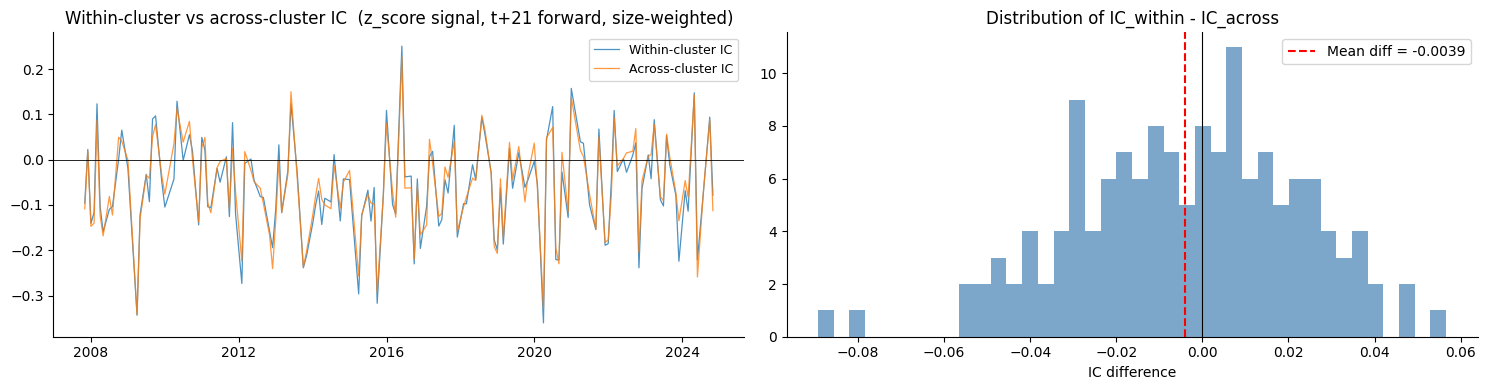

Mean IC within    : -0.0611
Mean IC across    : -0.0572
Mean difference   : -0.0039
t-stat NW         : -1.7835  (HAC corrected)
% dates within > across: 46.2%



In [12]:
ic_within_list = []
ic_across_list = []
date_list      = []

for d in rebal_dates.to_list()[:-1]:
    d_fwd = fwd_date(d, 21)
    if d_fwd is None:
        continue

    signals_d = S.filter(pl.col('rebal_date') == d).select(['symbol', 'cluster', 'z_score'])
    symbols_d = signals_d['symbol'].to_list()

    fwd = (
        R.filter(pl.col('symbol').is_in(symbols_d))
         .filter((pl.col('date') > d) & (pl.col('date') <= d_fwd))
         .group_by('symbol')
         .agg(pl.col('residual').sum().alias('fwd_ret'))
         .drop_nulls()
)

    merged = signals_d.join(fwd, on='symbol', how='inner')
    if len(merged) < 20:
        continue

    z_arr = merged['z_score'].to_numpy()
    f_arr = merged['fwd_ret'].to_numpy()
    c_arr = merged['cluster'].to_numpy()

    # Across-cluster IC: full universe
    ic_across = stats.spearmanr(z_arr, f_arr).statistic

    # Within-cluster IC: size-weighted average across clusters
    cluster_ics    = []
    cluster_sizes  = []
    for k in np.unique(c_arr):
        mask = c_arr == k
        if mask.sum() < 5:
            continue
        ic_k = stats.spearmanr(z_arr[mask], f_arr[mask]).statistic
        cluster_ics.append(ic_k)
        cluster_sizes.append(mask.sum())

    if not cluster_ics:
        continue

    # Size-weighted average
    weights  = np.array(cluster_sizes) / np.sum(cluster_sizes)
    ic_within = np.sum(weights * np.array(cluster_ics))

    ic_within_list.append(ic_within)
    ic_across_list.append(ic_across)
    date_list.append(datetime.strptime(str(d), '%Y-%m-%d'))

ic_within_arr = np.array(ic_within_list)
ic_across_arr = np.array(ic_across_list)
diff          = ic_within_arr - ic_across_arr

t_nw_diff  = newey_west_tstat(diff, max_lag=6)
_, p_iid   = stats.ttest_1samp(diff, 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(date_list, ic_within_arr, linewidth=0.9, label='Within-cluster IC', alpha=0.8)
axes[0].plot(date_list, ic_across_arr, linewidth=0.9, label='Across-cluster IC', alpha=0.8)
axes[0].axhline(0, color='k', linewidth=0.6)
axes[0].set_title('Within-cluster vs across-cluster IC  (z_score signal, t+21 forward, size-weighted)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_locator(mdates.YearLocator(4))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].hist(diff, bins=40, alpha=0.7, color='steelblue')
axes[1].axvline(0,          color='k',   linewidth=0.8)
axes[1].axvline(diff.mean(), color='red', linewidth=1.5, linestyle='--',
                label=f'Mean diff = {diff.mean():.4f}')
axes[1].set_title('Distribution of IC_within - IC_across')
axes[1].set_xlabel('IC difference')
axes[1].legend()

plt.tight_layout()
save_fig("04_signals_ic_within_across.png")
plt.show()
print(f'Mean IC within    : {ic_within_arr.mean():.4f}')
print(f'Mean IC across    : {ic_across_arr.mean():.4f}')
print(f'Mean difference   : {diff.mean():.4f}')
print(f't-stat NW         : {t_nw_diff:.4f}  (HAC corrected)')
print(f'% dates within > across: {(diff > 0).mean():.1%}')
print()

$H_0$ is not rejected, and while this certainly isn't ideal, it is likely the result of poor data limitations. It's simply not significant. Although, we can proceed with the portfolio as intented with the idea this would likely not hit prod.